In [1]:
from pathlib import Path

# --- Helper: choose between macOS-style and Windows-style roots ---
def pick_path(mac_path_str, win_path_str):
    mac_p = Path(mac_path_str)
    win_p = Path(win_path_str)
    if mac_p.exists():
        return mac_p
    elif win_p.exists():
        return win_p
    else:
        # Neither exists; return mac version but warn
        print(f"WARNING: Neither {mac_p} nor {win_p} exists on this system.")
        return mac_p

# --- Roots for BPB_proc (Session ? / main) ---
bpb_root = pick_path("/Volumes/HD-B1/BPB_proc", "E:/BPB_proc")

# --- Roots for SES-1 ---
ses1_root = pick_path(
    "/Volumes/HD-B1/Thesis/SES-1_BIDS/derivatives/afni_proc",
    "E:/Thesis/SES-1_BIDS/derivatives/afni_proc"
)

# --- Collect subject dirs (names only, like MATLAB dir('sub-*.results')) ---
def list_subject_dirs(root: Path, pattern="sub-*.results"):
    # glob pattern; keep only directories
    return sorted([p for p in root.glob(pattern) if p.is_dir()])

subject_dirs_1_paths = list_subject_dirs(bpb_root)
subject_dirs_2_paths = list_subject_dirs(ses1_root)

# MATLAB `subject_dirs_1 = {subject_dirs.name};`
subject_dirs_1 = [p.name for p in subject_dirs_1_paths]
subject_dirs_2 = [p.name for p in subject_dirs_2_paths]

# MATLAB `subject_dirs_full_1 = cellfun(@(s) fullfile(...), ...)`
# We already have full Paths from the glob results:
subject_dirs_full_1 = [str(p) for p in subject_dirs_1_paths]
subject_dirs_full_2 = [str(p) for p in subject_dirs_2_paths]

# --- Merge (MATLAB [a, b]) ---
bp_subject_dirs = subject_dirs_1 + subject_dirs_2
print(bp_subject_dirs)
bp_subject_dirs_full = subject_dirs_full_1 + subject_dirs_full_2

['sub-1.results', 'sub-10.results', 'sub-11.results', 'sub-12.results', 'sub-13.results', 'sub-15.results', 'sub-16.results', 'sub-17.results', 'sub-18.results', 'sub-19.results', 'sub-2.results', 'sub-20.results', 'sub-21.results', 'sub-22.results', 'sub-23.results', 'sub-4.results', 'sub-5.results', 'sub-6.results', 'sub-7.results', 'sub-8.results', 'sub-24.results', 'sub-25.results', 'sub-26.results', 'sub-27.results', 'sub-28.results', 'sub-29.results', 'sub-30.results', 'sub-31.results', 'sub-32.results', 'sub-33.results', 'sub-34.results', 'sub-36.results', 'sub-37.results', 'sub-38.results', 'sub-39.results', 'sub-40.results', 'sub-41.results', 'sub-42.results']


In [2]:
from pathlib import Path
import numpy as np
import warnings

# Glasser ROI indices: 1:180 and 1001:1180 (inclusive)
ROI_INDICES = list(range(1, 181)) + list(range(1001, 1181))  # 360 total


def BoldRoi_Subjects(subj):
    """
    Build a 360 x T BOLD matrix for a single subject from AFNI .1D ROI time series.

    Parameters
    ----------
    subj : str or pathlib.Path
        Path to the *subject directory* that contains the subfolder
        'Zscore_data_bandpass' with files named 'BOLD_<index>.1D', where
        <index> spans 1-180 and 1001-1180.

    Returns
    -------
    BOLD_matrix : np.ndarray, shape (360, T)
        Row = ROI (360 total), Column = timepoint.
        Missing or unreadable files become NaN rows.
    """
    subj = Path(subj)
    folder = subj / "Zscore_data_bandpass"

    # Build list of file paths in ROI order
    filepaths = [folder / f"BOLD_{i}.1D" for i in ROI_INDICES]

    # Determine T (time length) from the first file that exists & loads
    T = None
    for fp in filepaths:
        if fp.is_file():
            try:
                arr = np.loadtxt(fp, ndmin=1)
            except Exception as e:
                warnings.warn(f"Could not read {fp}: {e}")
                continue
            arr = np.asarray(arr).squeeze()
            if arr.ndim == 0:
                arr = arr[None]
            elif arr.ndim > 1:
                # Flatten but warn: unexpected shape
                warnings.warn(f"{fp} has shape {arr.shape}; flattening to 1D.")
                arr = arr.reshape(-1)
            T = arr.size
            break

    if T is None:
        raise FileNotFoundError(
            f"No readable BOLD_*.1D files found in {folder}."
        )

    # Preallocate
    BOLD_matrix = np.full((len(ROI_INDICES), T), np.nan, dtype=float)

    # Load each ROI
    for row, fp in enumerate(filepaths):
        if fp.is_file():
            try:
                arr = np.loadtxt(fp, ndmin=1)
                arr = np.asarray(arr).squeeze()
                if arr.ndim == 0:
                    arr = arr[None]
                elif arr.ndim > 1:
                    warnings.warn(f"{fp} has shape {arr.shape}; flattening to 1D.")
                    arr = arr.reshape(-1)

                if arr.size != T:
                    warnings.warn(
                        f"{fp} length {arr.size} != expected {T}; "
                        "truncating/padding with NaN."
                    )
                    if arr.size > T:
                        arr = arr[:T]
                    else:
                        tmp = np.full(T, np.nan)
                        tmp[:arr.size] = arr
                        arr = tmp

                BOLD_matrix[row, :] = arr

            except Exception as e:
                warnings.warn(f"Error reading {fp}: {e}; filling with NaN.")
                # Row stays NaN
        else:
            warnings.warn(f"Missing file: {fp}; filling with NaN.")

    return BOLD_matrix



In [3]:
# Suppose bp_subject_dirs_full is the merged list of subject directory *strings*
# (or Path objects) from the two roots, as shown previously.

BOLD_all_subjects_BP = [BoldRoi_Subjects(p) for p in bp_subject_dirs_full]
print(BOLD_all_subjects_BP)

# How many subjects?
n_subj = len(BOLD_all_subjects_BP)
print("N subjects:", n_subj)

# Check the first subject's matrix
print("First subject matrix shape:", BOLD_all_subjects_BP[0].shape)
print("First subject preview:\n", BOLD_all_subjects_BP[0][:5, :10])  # first 5 ROIs, 10 timepoints


[array([[ 0.256145, -0.041168, -0.12086 , ..., -0.002634, -0.033786,
         0.158722],
       [ 0.608073, -0.242999, -0.408318, ..., -0.5694  , -0.401144,
         0.662581],
       [ 0.785031, -0.004244, -0.471563, ...,  0.004966,  0.114299,
         0.709153],
       ...,
       [ 0.429095, -0.501431, -0.689352, ..., -0.275246, -0.149409,
         0.494838],
       [ 0.739472, -0.09611 , -0.915692, ...,  0.759714, -0.164551,
         0.114904],
       [-0.31531 ,  0.325854,  0.822305, ...,  0.480899,  0.027758,
        -0.412355]]), array([[-0.242657, -0.199818,  0.174392, ..., -0.095738, -0.0848  ,
        -0.074391],
       [ 0.037872,  0.476739,  0.520162, ...,  0.282731, -0.334801,
        -0.386018],
       [ 0.876739, -0.225953, -0.382351, ...,  0.299022, -0.725526,
         0.329756],
       ...,
       [ 0.247676,  0.259998,  0.054923, ...,  0.24978 ,  0.511099,
         0.322   ],
       [ 0.202561, -0.187302, -0.311077, ..., -0.219208, -0.098851,
         0.264528],
     

In [4]:
# Controls 
from pathlib import Path

# --- Helper reused from earlier ---
def pick_path(linux_path_str, mac_path_str):
    lin_p = Path(linux_path_str)
    mac_p = Path(mac_path_str)
    if lin_p.exists():
        return lin_p
    elif mac_p.exists():
        return mac_p
    else:
        print(f"WARNING: Neither {lin_p} nor {mac_p} exists; using Linux path string.")
        return lin_p  # fallback


# --- Root for HC subjects (Linux vs macOS given in MATLAB comments) ---
hc_root = pick_path(
    "E:/BIDS/derivatives/afni",
    "/Volumes/HD-B1/BIDS/derivatives/afni",
)

# --- Numeric subject IDs: MATLAB [35:38, 40:53, 55:57, 59:70] ---
subject_nums = (
    list(range(35, 39))  +  # 35-38 inclusive
    list(range(40, 54))  +  # 40-53 inclusive
    list(range(55, 58))  +  # 55-57 inclusive
    list(range(59, 71))     # 59-70 inclusive
)

# --- Build folder names like 'sub-35.results' ---
hc_subject_dirs = [f"sub-{n}.results" for n in subject_nums]

# --- Full paths ---
hc_subject_dirs_full = [hc_root / d for d in hc_subject_dirs]

# --- Apply BoldRoi_Subjects (defined previously) ---
BOLD_all_subjects_HC = [BoldRoi_Subjects(p) for p in hc_subject_dirs_full]


In [5]:
# How many subjects?
n_subj = len(BOLD_all_subjects_BP)
print("N subjects:", n_subj)

# Check the first subject's matrix
print("First subject matrix shape:", BOLD_all_subjects_BP[0].shape)
print("First subject preview:\n", BOLD_all_subjects_BP[0][:5, :10])  # first 5 ROIs, 10 timepoints

N subjects: 38
First subject matrix shape: (360, 158)
First subject preview:
 [[ 0.256145 -0.041168 -0.12086   0.267293  0.224749 -0.467863 -0.736374
  -0.292406 -0.012366 -0.050109]
 [ 0.608073 -0.242999 -0.408318 -0.222191 -0.463518 -0.607563 -0.276076
   0.193427  0.774041  1.181007]
 [ 0.785031 -0.004244 -0.471563 -0.146604 -0.102025 -0.658302 -0.68475
   0.168301  0.709609  0.180431]
 [ 0.399988 -0.098209 -0.407453 -0.083618  0.146326 -0.043695 -0.091584
   0.050982 -0.065048 -0.284285]
 [ 0.393644 -0.162063 -0.269983  0.083361  0.139656 -0.148391 -0.212579
  -0.035983 -0.025354 -0.270619]]


In [6]:
import numpy as np
from scipy import signal


def median_frequency(
    x,
    fs,
    freqrange,
    method: str = "welch",
    nperseg: int | None = None,
    noverlap: int | None = None,
    window="hann",
):
    """
    Median Frequency (MF): the frequency that divides the power spectral density (PSD)
    such that half the total power in the specified frequency range is below
    and half is above.

    Parameters
    ----------
    x : array_like
        1D time series.
    fs : float
        Sampling frequency (Hz).
    freqrange : tuple[float, float] or list[float, float]
        Frequency-of-interest bounds (low, high), e.g., (1, 50).
    method : {"welch", "periodogram"}, default "welch"
        PSD estimation method.
    nperseg : int, optional
        Segment length for Welch. If None, SciPy default is used.
        Consider supplying a length that captures ~2–3 cycles of lowest freq.
    noverlap : int, optional
        Overlap for Welch (samples). If None, SciPy default ~nperseg//2.
    window : str or tuple or array_like, default "hann"
        Window for Welch/periodogram.

    Returns
    -------
    MF : float
        Median frequency in Hz. np.nan if PSD empty in range or inputs invalid.
    freq : ndarray
        Frequency vector actually used (subset in range).
    psd : ndarray
        PSD values in the selected range (same length as freq).

    Notes
    -----
    - Data are treated as 1D; if multi-dim, flattened.
    - Power is computed from the one-sided PSD returned by SciPy (for real signals).
    - If no samples fall inside `freqrange`, returns np.nan.
    """
    x = np.asarray(x).ravel()

    if method.lower() == "welch":
        freq, psd = signal.welch(
            x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend="constant"
        )
    elif method.lower() == "periodogram":
        freq, psd = signal.periodogram(x, fs=fs, window=window, detrend="constant")
    else:
        raise ValueError("method must be 'welch' or 'periodogram'")

    f_lo, f_hi = float(freqrange[0]), float(freqrange[1])
    mask = (freq > f_lo) & (freq < f_hi)
    freq2 = freq[mask]
    psd2 = psd[mask]

    if freq2.size == 0:
        return np.nan, freq2, psd2

    cum_power = np.cumsum(psd2)
    half_power = cum_power[-1] / 2.0
    idx = np.argmax(cum_power >= half_power)
    MF = freq2[idx]

    return MF, freq2, psd2


def mf_per_roi(mat, fs, freqrange, **mf_kwargs):
    """
    Compute median frequency for each ROI (row) in a (n_roi, T) matrix.

    Parameters
    ----------
    mat : ndarray, shape (n_roi, T)
        BOLD data (rows = ROIs).
    fs : float
        Sampling frequency (Hz).
    freqrange : (float, float)
        Frequency-of-interest bounds.
    **mf_kwargs :
        Passed through to `median_frequency` (method, nperseg, etc.).

    Returns
    -------
    mf_vals : ndarray, shape (n_roi,)
        Median frequency per ROI. NaN where row invalid / all NaN.
    """
    n_roi, _ = mat.shape
    mf_vals = np.full(n_roi, np.nan, dtype=float)

    for i in range(n_roi):
        row = mat[i, :]
        # Skip if all NaN or too few finite samples
        finite = np.isfinite(row)
        if finite.sum() < 2:
            continue  # leave NaN
        MF, _, _ = median_frequency(row[finite], fs=fs, freqrange=freqrange, **mf_kwargs)
        mf_vals[i] = MF
    return mf_vals


In [7]:
# REQUIRED: define your sampling freq and freq range
fs = 1/3  # <-- example; REPLACE with your actual sampling frequency in Hz
freqrange = (0.01, 0.1)  # <-- example; REPLACE

# Optional Welch params (example: ~2.5 cycles at lowest freq)
lowest_f = freqrange[0]
nperseg = int(round((2.5 / lowest_f) * fs)) if lowest_f > 0 else None

mf_bp_subjects = [
    mf_per_roi(mat, fs=fs, freqrange=freqrange, nperseg=nperseg)
    for mat in BOLD_all_subjects_BP
]

mf_hc_subjects = [
    mf_per_roi(mat, fs=fs, freqrange=freqrange, nperseg=nperseg)
    for mat in BOLD_all_subjects_HC
]


In [8]:
mf_subjects_bp_arr = np.vstack(mf_bp_subjects)  # shape (N_subjects, 360)
mf_subjects_hc_arr = np.vstack(mf_hc_subjects)  # shape (N_subjects, 360)

# Count
n = len(hc_subject_dirs)  # 33

# Build new sequential names starting from 43
start_id = 43
hc_subject_dirs_renum = [f"sub-{start_id + i}.results" for i in range(n)]
print(hc_subject_dirs_renum)

import pandas as pd

mf_df_bp = pd.DataFrame(mf_subjects_bp_arr, index=bp_subject_dirs)  # subjects as rows, ROIs as cols
mf_df_hc = pd.DataFrame(mf_subjects_hc_arr, index=hc_subject_dirs_renum)  # subjects as rows, ROIs as cols

mf_df_bp.index.name = "subject"
mf_df_hc.index.name = "subject"

df_all = pd.concat([mf_df_bp, mf_df_hc], axis=0, ignore_index=False)
print(df_all)



['sub-43.results', 'sub-44.results', 'sub-45.results', 'sub-46.results', 'sub-47.results', 'sub-48.results', 'sub-49.results', 'sub-50.results', 'sub-51.results', 'sub-52.results', 'sub-53.results', 'sub-54.results', 'sub-55.results', 'sub-56.results', 'sub-57.results', 'sub-58.results', 'sub-59.results', 'sub-60.results', 'sub-61.results', 'sub-62.results', 'sub-63.results', 'sub-64.results', 'sub-65.results', 'sub-66.results', 'sub-67.results', 'sub-68.results', 'sub-69.results', 'sub-70.results', 'sub-71.results', 'sub-72.results', 'sub-73.results', 'sub-74.results', 'sub-75.results']
                     0         1         2         3         4         5    \
subject                                                                      
sub-1.results   0.044177  0.040161  0.044177  0.040161  0.044177  0.048193   
sub-10.results  0.040161  0.064257  0.048193  0.048193  0.060241  0.036145   
sub-11.results  0.044177  0.060241  0.052209  0.032129  0.040161  0.040161   
sub-12.results 

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"

# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

# If the file has no header row and just two columns, uncomment:
# ctrl_df = pd.read_csv(ctrl_csv, header=None, names=["transmodal", "unimodal"])

# Ensure we have at least two columns
if ctrl_df.shape[1] < 2:
    raise ValueError("controlregions.csv must have at least two columns (transmodal, unimodal).")

# Normalize column names (optional but convenient)
ctrl_df = ctrl_df.rename(columns=lambda c: str(c).strip().lower())

# Try to find columns by name; fall back to positional
trans_col = next((c for c in ctrl_df.columns if "trans" in c), ctrl_df.columns[0])
uni_col   = next((c for c in ctrl_df.columns if "uni" in c),   ctrl_df.columns[1])

transmask_raw = ctrl_df[trans_col].to_numpy()
unimask_raw   = ctrl_df[uni_col].to_numpy()

# --- Coerce to boolean masks ---
# Treat nonzero & non-null as True
transmask = np.asarray(transmask_raw, dtype=float)
unimask   = np.asarray(unimask_raw, dtype=float)

# If any NaNs, treat as 0
transmask = np.nan_to_num(transmask, nan=0.0)
unimask   = np.nan_to_num(unimask,   nan=0.0)

transmask_bool = transmask.astype(bool)
unimask_bool   = unimask.astype(bool)

# --- Check mask lengths vs df_all columns ---
n_roi_mask = len(transmask_bool)
n_roi_df   = df_all.shape[1]

if n_roi_mask != n_roi_df:
    raise ValueError(
        f"Mask length ({n_roi_mask}) != number of ROI columns in df_all ({n_roi_df}). "
        "We need a mapping or confirmation of ROI order."
    )

# --- Compute subject means across masked ROIs ---
# df_all: subjects × ROIs
MF_transmodal = df_all.loc[:, transmask_bool].mean(axis=1, skipna=True)
MF_unimodal   = df_all.loc[:, unimask_bool].mean(axis=1, skipna=True)

# --- Append to df_all ---
df_all = df_all.copy()
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal



In [10]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. Load BP sheet (Excel): has SubjectID, Total Score, Age, Sex
# ------------------------------------------------------------------
bp_subj = pd.read_excel(
    r"C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/raw/BDI_ThreeFactor_MultiSubject.xlsx"
)

# Standardize column names just in case
bp_subj = bp_subj.rename(columns=lambda c: str(c).strip())

# Rename Total Score -> BDI; keep needed columns
bp_use = (
    bp_subj.rename(columns={"Total Score": "BDI"})[["SubjectID", "BDI", "Age", "Sex"]]
    .assign(Group="BP")
)

# ------------------------------------------------------------------
# 2. Load HC participants slice from TSV and drop exclusions
# ------------------------------------------------------------------
df = pd.read_csv(r"E:/BIDS/participants.tsv", sep="\t")

# R slice(35:70) => pandas iloc[34:70] (sub-35..sub-70 inclusive in R)
df_slice = df.iloc[34:70].copy()

exclude_ids = ["sub-54", "sub-39", "sub-58"]
hc_subj = df_slice.loc[~df_slice["participant_id"].isin(exclude_ids)].copy()

# Number of HC subjects kept
n = len(hc_subj)

# ------------------------------------------------------------------
# 3. Build renumbered HC ID list starting at 43
# ------------------------------------------------------------------
start_id = 43
hc_ids_renum = [f"sub-{start_id + i}" for i in range(n)]

# Create HC BDI/demographics DataFrame with renumbered IDs
hc_bdi_renum_df = pd.DataFrame({
    "SubjectID": hc_ids_renum,
    "BDI": pd.to_numeric(hc_subj["BDI"], errors="coerce"),
    "Age": pd.to_numeric(hc_subj["Age"], errors="coerce"),
    "Sex": pd.to_numeric(hc_subj["Sex"], errors="coerce"),
    "Group": "HC",   # one value broadcast to all rows
})

# ------------------------------------------------------------------
# 4. Combine BP + HC into one BDI/demographics table
# ------------------------------------------------------------------
bdi_df = pd.concat([bp_use, hc_bdi_renum_df], axis=0, ignore_index=True)

# Ensure BDI numeric
bdi_df["BDI"] = pd.to_numeric(bdi_df["BDI"], errors="coerce")

# ------------------------------------------------------------------
# 5. Prepare df_all imaging data
#     (Assumes df_all already exists & MF_transmodal / MF_unimodal arrays ready)
# ------------------------------------------------------------------
df_all = df_all.copy()

# Add MF columns if not already present
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal

# Add clean SubjectID (strip ".results")
df_all["SubjectID"] = df_all.index.to_series().str.replace(".results", "", regex=False)

# ------------------------------------------------------------------
# 6. Merge BDI + Age + Sex into df_all by SubjectID
# ------------------------------------------------------------------
df_all = df_all.merge(
    bdi_df,                # has SubjectID, BDI, Age, Sex
    on="SubjectID",
    how="left",
    validate="m:1"         # one demographic row per SubjectID expected
)

# ------------------------------------------------------------------
# 7. Final metrics table with Age & Sex at the end
# ------------------------------------------------------------------
df_metrics = df_all.loc[:, ["SubjectID", "Group","BDI", "MF_transmodal", "MF_unimodal", "Age", "Sex"]].reset_index(drop=True)

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       0.044846     0.045445  56.0  2.0
1    sub-10    BP  30.0       0.045956     0.048263  26.0  2.0
2    sub-11    BP  44.0       0.046675     0.049496  54.0  1.0
3    sub-12    BP  38.0       0.042234     0.048686  40.0  1.0
4    sub-13    BP  22.0       0.040716     0.045868  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
66    sub-71    HC  2.0       0.048470     0.044459  22.0  2.0
67    sub-72    HC  3.0       0.051572     0.053900  31.0  1.0
68    sub-73    HC  0.0       0.049238     0.052315  28.0  1.0
69    sub-74    HC  8.0       0.050021     0.054358  46.0  2.0
70    sub-75    HC  1.0       0.053009     0.053794  20.0  2.0
Shape: (71, 7)
Missing BDI: 1


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# df_metrics is your tidy table: SubjectID, Group, BDI, MF_transmodal, MF_unimodal, Age, Sex

dat = df_metrics.copy()

# --- Z-scores (match R scale()) ---
scaler = StandardScaler()

dat["age_z"]        = scaler.fit_transform(dat[["Age"]])
dat["unimodal_z"]   = scaler.fit_transform(dat[["MF_unimodal"]])
dat["transmodal_z"] = scaler.fit_transform(dat[["MF_transmodal"]])
dat["BDI_z"]        = scaler.fit_transform(dat[["BDI"]])  # the outcome

# --- Factors ---
# Ensure BP is baseline (0), HC = 1 (treatment coding like brms default)
dat["group"] = pd.Categorical(dat["Group"], categories=["BP", "HC"])  # specify order!
g_idx = dat["group"].cat.codes.to_numpy()  # 0=BP, 1=HC

# Sex as categorical (if coded 1=male, 2=female; we treat numeric but mean-center)
# If truly categorical, do similar to group:
dat["sex_cat"] = pd.Categorical(dat["Sex"])    # automatic categories (1.0, 2.0)
s_idx = dat["sex_cat"].cat.codes.to_numpy()    # 0,1,...  (here 0=1.0, 1=2.0)
# or just standardize numeric: dat["sex_z"] = (dat["Sex"] - dat["Sex"].mean())/dat["Sex"].std()

# Design vectors
unimodal_z   = dat["unimodal_z"].to_numpy()
transmodal_z = dat["transmodal_z"].to_numpy()
age_z        = dat["age_z"].to_numpy()
BDI_z        = dat["BDI_z"].to_numpy()

# Group indicator (0/1) for interaction coding
group_HC = (g_idx == 1).astype(float)  # BP=0, HC=1
# Sex indicator: up to you; here 1 if category code==1 else 0
sex_1 = (s_idx == 1).astype(float)     # adjust to taste
print(dat)
#dat.to_csv("C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/data/output/MF_indexed.csv", index=True)


   SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex     age_z  \
0      sub-1    BP   8.0       0.044846     0.045445  56.0  2.0  1.715244   
1     sub-10    BP  30.0       0.045956     0.048263  26.0  2.0 -1.035863   
2     sub-11    BP  44.0       0.046675     0.049496  54.0  1.0  1.531837   
3     sub-12    BP  38.0       0.042234     0.048686  40.0  1.0  0.247987   
4     sub-13    BP  22.0       0.040716     0.045868  52.0  2.0  1.348430   
..       ...   ...   ...            ...          ...   ...  ...       ...   
66    sub-71    HC   2.0       0.048470     0.044459  22.0  2.0 -1.402677   
67    sub-72    HC   3.0       0.051572     0.053900  31.0  1.0 -0.577345   
68    sub-73    HC   0.0       0.049238     0.052315  28.0  1.0 -0.852456   
69    sub-74    HC   8.0       0.050021     0.054358  46.0  2.0  0.798208   
70    sub-75    HC   1.0       0.053009     0.053794  20.0  2.0 -1.586084   

    unimodal_z  transmodal_z     BDI_z group sex_cat  
0    -0.196685     -

KeyError: 'mu'

In [14]:
import numpy as np
import pandas as pd

# If dat_bmb not already defined:
dat_bmb = df_metrics.copy()
dat_bmb = dat_bmb.dropna(subset=["BDI"]).reset_index(drop=True)

def zscore(s): return (s - s.mean()) / s.std(ddof=0)

dat_bmb["unimodal_z"]   = zscore(dat_bmb["MF_unimodal"])
dat_bmb["transmodal_z"] = zscore(dat_bmb["MF_transmodal"])
dat_bmb["age_z"]        = zscore(dat_bmb["Age"])
dat_bmb["BDI_z"]        = zscore(dat_bmb["BDI"])

# categorical group with BP baseline
dat_bmb["group"] = pd.Categorical(dat_bmb["Group"], categories=["BP","HC"], ordered=True)

print(dat_bmb[["SubjectID","group","BDI_z","unimodal_z","transmodal_z","age_z"]].head())

# Outcome
y = dat_bmb["BDI_z"].to_numpy()

# Predictors
U  = dat_bmb["unimodal_z"].to_numpy()
T_ = dat_bmb["transmodal_z"].to_numpy()
A  = dat_bmb["age_z"].to_numpy()

# Group dummy (HC=1, BP=0)
G1 = (dat_bmb["group"] == "HC").astype(float).to_numpy()

# Interaction terms
U_G = U  * G1
T_G = T_ * G1

# Mean model (exclude intercept; we'll sample intercept separately)
X_mean = np.column_stack([U, T_, G1, A, U_G, T_G])
mean_terms = ["unimodal_z", "transmodal_z", "group_HC", "age_z",
              "unimodal_z:group_HC", "transmodal_z:group_HC"]

# Group design for σ and ν (two columns: BP, HC)
# 1-hot coding
X_grp = np.column_stack([1.0 - G1, G1])  # col0=BP, col1=HC

print("X_mean shape:", X_mean.shape, "terms:", mean_terms)
print("X_grp shape:", X_grp.shape, "cols: ['BP','HC']")

import pymc as pm
import pytensor.tensor as pt
import numpy as np

N, P = X_mean.shape
_, Gs = X_grp.shape  # should be 2

with pm.Model() as model_grp:

    # --- Mean ---
    Intercept = pm.Normal("Intercept", mu=0.0, sigma=0.50)
    b = pm.Normal("b", mu=0.0, sigma=0.30, shape=P)  # mean slopes
    mu = Intercept + pt.dot(X_mean, b)

    # --- sigma (log-link) ---
    b_sigma = pm.Normal("b_sigma", mu=0.0, sigma=0.30, shape=Gs)  # log σ_BP, log σ_HC coeffs
    log_sigma = pt.dot(X_grp, b_sigma)
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma))

    # --- nu (log-link) ---
    b_nu = pm.Normal("b_nu", mu=np.log(10.0), sigma=0.50, shape=Gs)  # log ν_BP, log ν_HC coeffs
    log_nu = pt.dot(X_grp, b_nu)
    nu = pm.Deterministic("nu", pt.exp(log_nu))

    # --- Likelihood ---
    pm.StudentT("BDI_z", mu=mu, sigma=sigma, nu=nu, observed=y)

    # --- Sample ---
    idata_grp = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=123,
        mp_ctx="spawn",  # explicit
    )


  SubjectID group     BDI_z  unimodal_z  transmodal_z     age_z
0     sub-1    BP -0.622094   -0.210053     -0.173841  1.722301
1    sub-10    BP  0.686683    0.426815      0.174867 -1.021881
2    sub-11    BP  1.519540    0.705445      0.400502  1.539355
3    sub-12    BP  1.162601    0.522345     -0.994332  0.258737
4    sub-13    BP  0.210764   -0.114522     -1.471242  1.356410
X_mean shape: (70, 6) terms: ['unimodal_z', 'transmodal_z', 'group_HC', 'age_z', 'unimodal_z:group_HC', 'transmodal_z:group_HC']
X_grp shape: (70, 2) cols: ['BP','HC']


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, b, b_sigma, b_nu]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 86 seconds.


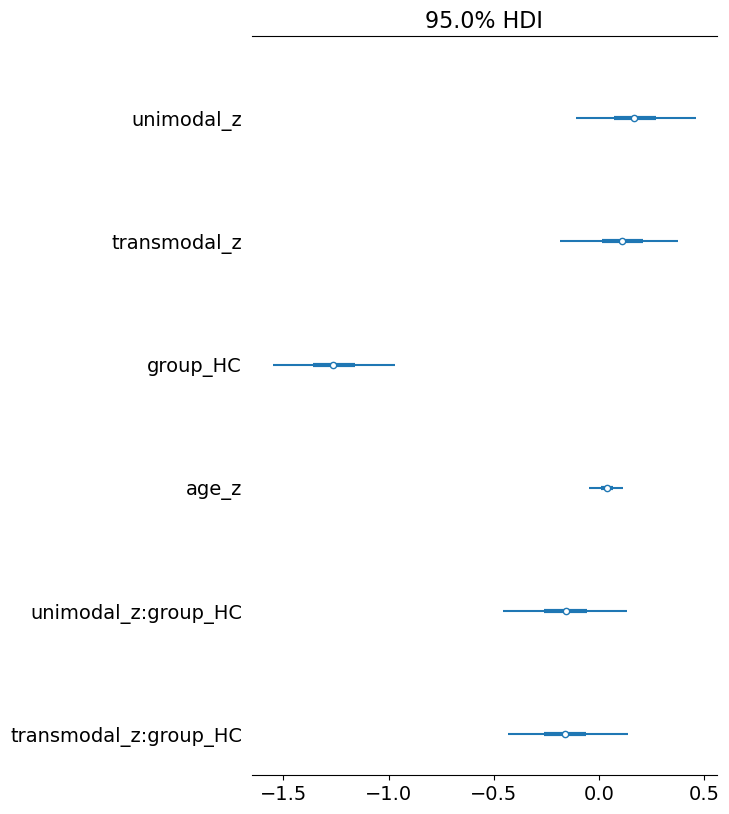

In [34]:
import arviz as az

# Order must match the way you built X_mean
mean_terms = [
    "unimodal_z",
    "transmodal_z",
    "group_HC",
    "age_z",
    "unimodal_z:group_HC",
    "transmodal_z:group_HC",
]

# Grab the beta vector from your fitted model
post_b = idata_grp.posterior["b"]   # dims: ('chain','draw','b_dim_0') in your case

# Detect the actual beta index dim name automatically
b_dim_name = post_b.dims[-1]        # should be 'b_dim_0'

# Build dict: each predictor name -> array(chain, draw)
posterior_dict = {
    name: post_b.isel({b_dim_name: i}).values for i, name in enumerate(mean_terms)
}

# Convert to a small labelled InferenceData
idata_betas = az.from_dict(posterior=posterior_dict)

# Forest plot with readable names
az.plot_forest(
    idata_betas,
    var_names=mean_terms,
    combined=True,
    hdi_prob=0.95,
);


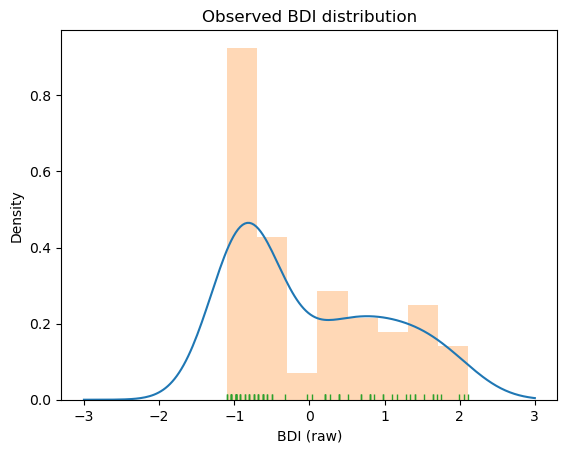

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde  # if not installed: conda install scipy

x = dat_bmb["BDI_z"].dropna().to_numpy()
xs = np.linspace(-3, 3, 200)

kde = gaussian_kde(x)
plt.figure()
plt.plot(xs, kde(xs))          # density curve
plt.hist(x, bins="auto", density=True, alpha=0.3)  # light histogram background
plt.plot(x, np.zeros_like(x), "|", markersize=8)   # rug ticks
plt.xlabel("BDI (raw)")
plt.ylabel("Density")
plt.title("Observed BDI distribution");


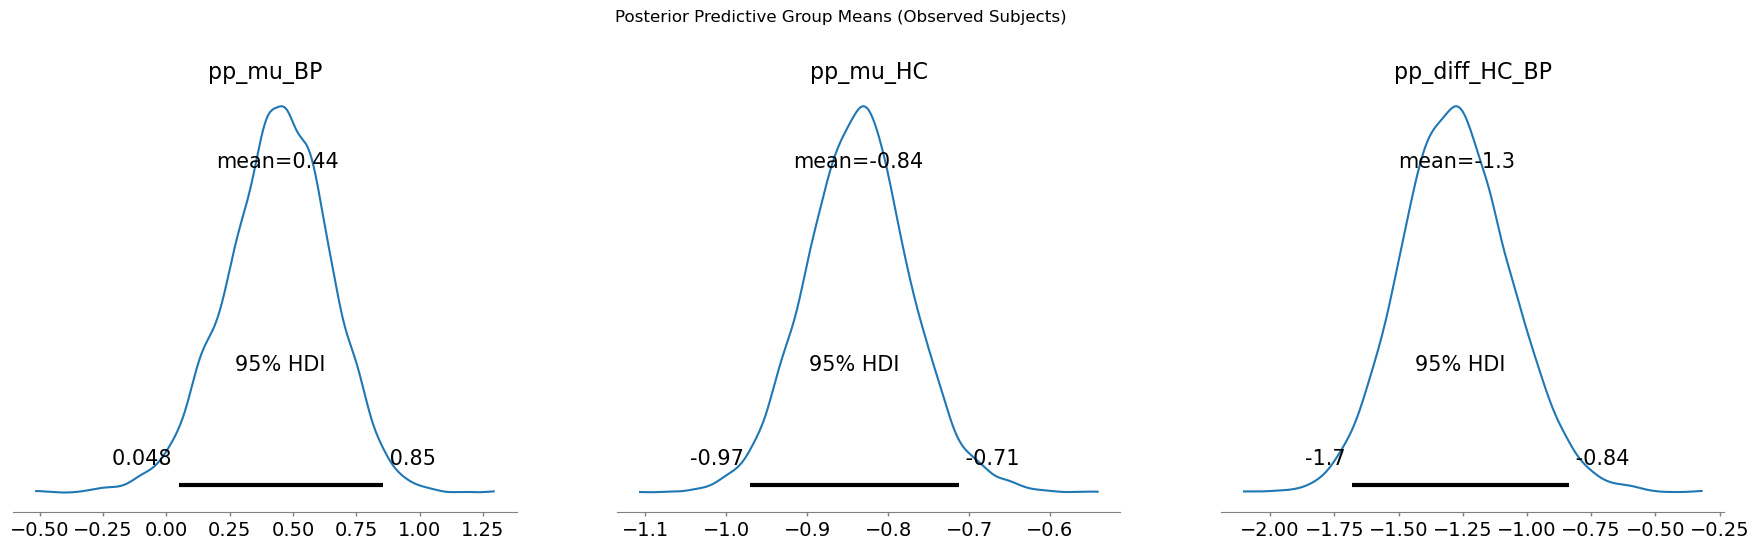

In [38]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# Posterior predictive draws: (chain, draw, subject)
pp_da = idata_pp.posterior_predictive["BDI_z"]

# Flatten chain+draw -> sample
pp_flat_da = pp_da.stack(sample=("chain", "draw"))  # dims: sample, BDI_z_dim_0
# Ensure sample is first axis for .values
pp_flat_da = pp_flat_da.transpose("sample", "BDI_z_dim_0")

pp_flat = pp_flat_da.values   # shape: (n_samples, n_subjects)

# Masks for groups from your analysis dataframe
mask_hc = (dat_bmb["group"] == "HC").to_numpy()
mask_bp = ~mask_hc

# Sample-wise group means
pp_mu_BP = pp_flat[:, mask_bp].mean(axis=1)
pp_mu_HC = pp_flat[:, mask_hc].mean(axis=1)
pp_diff  = pp_mu_HC - pp_mu_BP

# Plot posterior densities + 95% HDIs
az.plot_posterior(
    {"pp_mu_BP": pp_mu_BP, "pp_mu_HC": pp_mu_HC, "pp_diff_HC_BP": pp_diff},
    hdi_prob=0.95,
    point_estimate="mean",
);
plt.suptitle("Posterior Predictive Group Means (Observed Subjects)", y=1.02);


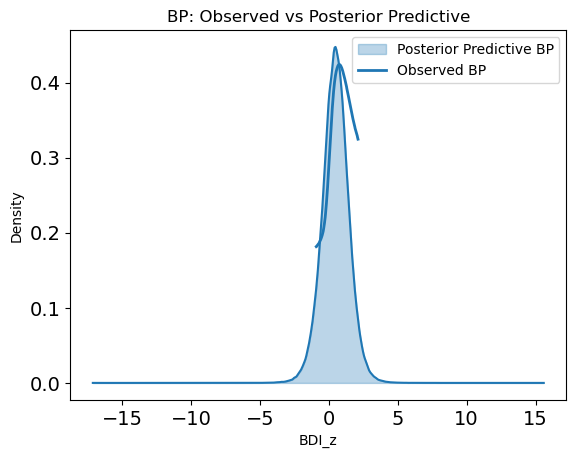

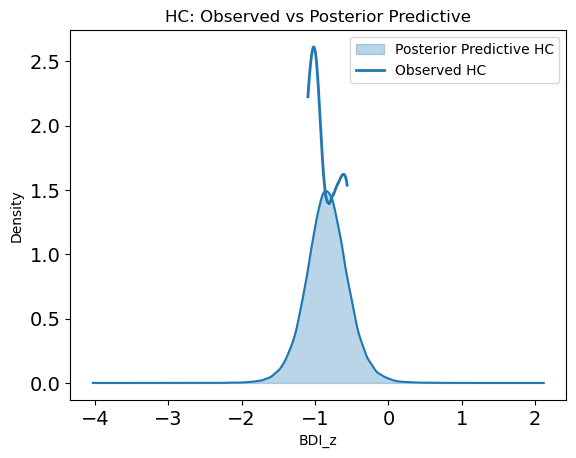

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# --- Posterior predictive draws: (chain, draw, subject) ---
pp_da = idata_pp.posterior_predictive["BDI_z"]

# Flatten chain+draw -> sample; put sample axis first
pp_da_flat = pp_da.stack(sample=("chain", "draw")).transpose("sample", "BDI_z_dim_0")
pp_flat = pp_da_flat.values  # shape: (n_samples, n_subjects)

# Observed data (in same subject order)
obs = dat_bmb["BDI_z"].to_numpy()

# Group masks
mask_hc = (dat_bmb["group"] == "HC").to_numpy()
mask_bp = ~mask_hc

assert len(obs) == pp_flat.shape[1], "Subject count mismatch!"

# Pool posterior predictive draws across subjects in each group
pp_BP_vals = pp_flat[:, mask_bp].ravel()
pp_HC_vals = pp_flat[:, mask_hc].ravel()

# --- Plot: BP ---
plt.figure()
az.plot_kde(pp_BP_vals, label="Posterior Predictive BP", fill_kwargs={"alpha":0.3})
az.plot_kde(obs[mask_bp], label="Observed BP", plot_kwargs={"linewidth":2})
plt.xlabel("BDI_z")
plt.ylabel("Density")
plt.title("BP: Observed vs Posterior Predictive")
plt.legend()

# --- Plot: HC ---
plt.figure()
az.plot_kde(pp_HC_vals, label="Posterior Predictive HC", fill_kwargs={"alpha":0.3})
az.plot_kde(obs[mask_hc], label="Observed HC", plot_kwargs={"linewidth":2})
plt.xlabel("BDI_z")
plt.ylabel("Density")
plt.title("HC: Observed vs Posterior Predictive")
plt.legend()

plt.show()
